# Complete Machine Learning Lifecycle Notebook
This notebook demonstrates the **entire ML lifecycle** using a dataset of 10,000 student records.

Students will:
- Perform EDA
- Handle missing values
- Do feature engineering
- Apply feature selection
- Train classification model
- Train regression model
- Evaluate models
- Make predictions


## 1. Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.linear_model import LogisticRegression, LinearRegression


## 2. Load Dataset

In [30]:
df = pd.read_csv('student_performance_ml_dataset_10000.csv')
df.head()

,study_hours_per_week,attendance_percentage,previous_exam_score,sleep_hours,assignments_completed,stress_level,practice_tests_taken,pass_exam,final_exam_score
0,13.986857,73.215053,70.224294,3.529142,2,9,4,1,97.042689
1,11.446943,76.945005,69.249854,NaN,5,4,3,0,96.015519
2,14.590754,74.026189,50.952202,5.619457,3,1,3,0,80.661404
3,18.092119,81.104180,73.693763,6.724503,3,4,2,1,98.455899
4,11.063387,91.971785,42.648760,8.036243,4,6,0,0,72.834012


## 3. Basic Data Understanding

In [31]:
df.shape

(10000, 9)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours_per_week   10000 non-null  float64
 1   attendance_percentage  10000 non-null  float64
 2   previous_exam_score    10000 non-null  float64
 3   sleep_hours            9200 non-null   float64
 4   assignments_completed  10000 non-null  int64  
 5   stress_level           10000 non-null  int64  
 6   practice_tests_taken   10000 non-null  int64  
 7   pass_exam              10000 non-null  int64  
 8   final_exam_score       10000 non-null  float64
dtypes: float64(5), int64(4)
memory usage: 703.3 KB


In [33]:
df.describe()

,study_hours_per_week,attendance_percentage,previous_exam_score,sleep_hours,assignments_completed,stress_level,practice_tests_taken,pass_exam,final_exam_score
count,10000.000000,10000.000000,10000.000000,9200.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.993180,80.046760,64.773571,6.493615,4.511200,5.006900,3.506800,0.416700,87.695300
std,4.008170,9.800043,14.765300,1.477696,2.885881,2.584941,2.289602,0.493037,11.285348
min,0.000000,41.436247,10.173702,3.000000,0.000000,1.000000,0.000000,0.000000,33.641351
25%,9.309638,73.379891,54.497721,5.462516,2.000000,3.000000,2.000000,0.000000,79.987076
50%,11.989620,80.158467,64.913476,6.483828,5.000000,5.000000,4.000000,0.000000,89.570419
75%,14.684324,86.938649,74.958461,7.520647,7.000000,7.000000,6.000000,1.000000,98.870732
max,27.704951,100.000000,100.000000,10.000000,9.000000,9.000000,7.000000,1.000000,100.000000


## 4. Missing Values Analysis

In [34]:
df.isnull().sum()

study_hours_per_week       0
attendance_percentage      0
previous_exam_score        0
sleep_hours              800
assignments_completed      0
stress_level               0
practice_tests_taken       0
pass_exam                  0
final_exam_score           0
dtype: int64

In [35]:
df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_14860\3351743532.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)


## 5. Exploratory Data Analysis

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


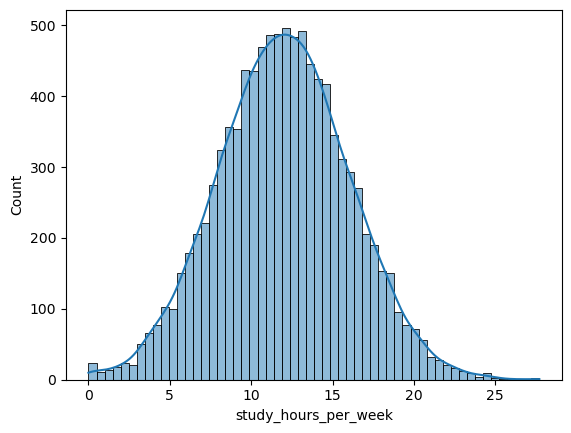

In [36]:
plt.figure()
sns.histplot(df['study_hours_per_week'], kde=True)
plt.show()

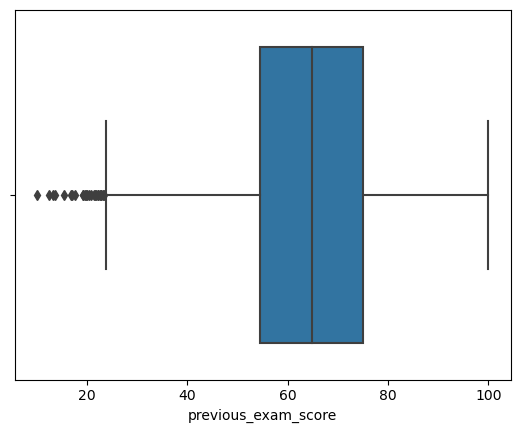

In [37]:
plt.figure()
sns.boxplot(x=df['previous_exam_score'])
plt.show()

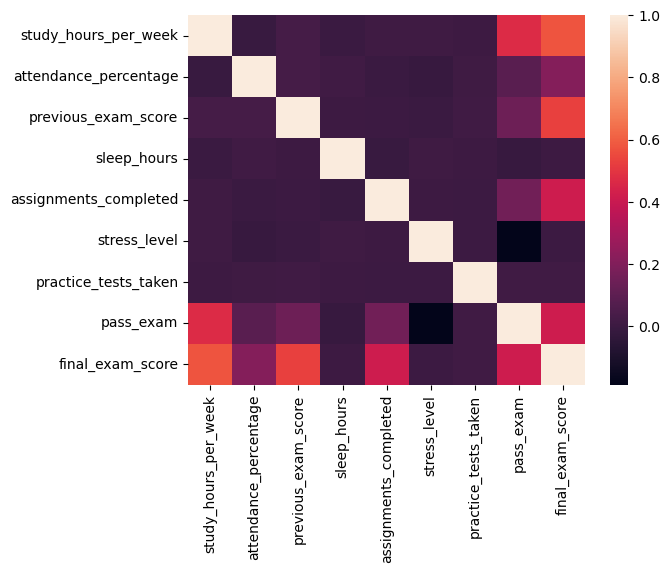

In [38]:
plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.show()

## 6. Feature Engineering

### Instructor Task
Create study_efficiency feature

In [39]:
df['study_efficiency'] = df['study_hours_per_week'] * df['attendance_percentage']
df.head()

,study_hours_per_week,attendance_percentage,previous_exam_score,sleep_hours,assignments_completed,stress_level,practice_tests_taken,pass_exam,final_exam_score,study_efficiency
0,13.986857,73.215053,70.224294,3.529142,2,9,4,1,97.042689,1024.048444
1,11.446943,76.945005,69.249854,6.483828,5,4,3,0,96.015519,880.785075
2,14.590754,74.026189,50.952202,5.619457,3,1,3,0,80.661404,1080.097930
3,18.092119,81.104180,73.693763,6.724503,3,4,2,1,98.455899,1467.346519
4,11.063387,91.971785,42.648760,8.036243,4,6,0,0,72.834012,1017.519408


In [40]:
# Drop Unnecassary column


### Student Task
Create at least **two new engineered features**.

## 7. Feature Selection

### Instructor Task
Use correlation method to identify important features.

In [41]:
corr = df.corr()
corr['pass_exam'].sort_values(ascending=False)

pass_exam                1.000000
study_efficiency         0.468322
study_hours_per_week     0.466930
final_exam_score         0.412118
assignments_completed    0.158067
previous_exam_score      0.144888
attendance_percentage    0.086931
practice_tests_taken     0.013924
sleep_hours             -0.014510
stress_level            -0.187999
Name: pass_exam, dtype: float64

### Student Task
Remove low correlation columns.

# Activity

### Use other 2 more feature selection techniques to make sure you are dropping correct columns

## 8. Classification Problem

Target: pass_exam


In [42]:
X = df.drop(['pass_exam','final_exam_score'], axis=1)
y = df['pass_exam']

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
X_train.shape

(8000, 8)

In [45]:
y_train.shape

(8000,)

# To resolve outliers normalize values

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Instructor Model: Logistic Regression

In [47]:
model = LogisticRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)

### Evaluation Metrics

In [48]:
print('Accuracy:', accuracy_score(y_test,pred))
print('Precision:', precision_score(y_test,pred))
print('Recall:', recall_score(y_test,pred))
print('F1 Score:', f1_score(y_test,pred))
print('AUC:', roc_auc_score(y_test,pred))

Accuracy: 0.76
Precision: 0.7510148849797023
Recall: 0.6521739130434783
F1 Score: 0.6981132075471698
AUC: 0.7460173307602074


### Student Task
Train at least **two more classification models** and compare performance.

## 9. Regression Problem

Now the target becomes **final_exam_score**

In [23]:
X = df.drop(['final_exam_score','pass_exam'],axis=1)
y = df['final_exam_score']

In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Instructor Model: Linear Regression

In [25]:
reg_model = LinearRegression()
reg_model.fit(X_train,y_train)
pred = reg_model.predict(X_test)

### Regression Evaluation Metrics

In [26]:
mse = mean_squared_error(y_test,pred)
mae = mean_absolute_error(y_test,pred)
rmse = np.sqrt(mse)
sse = mse * len(y_test)

print('MSE:', mse)
print('MAE:', mae)
print('RMSE:', rmse)
print('SSE:', sse)

MSE: 25.033459426012474
MAE: 4.02737723529099
RMSE: 5.003344823816611
SSE: 50066.918852024944


### Student Task
Implement **two more regression models** and compare results.

## 10. Prediction Section

### Classification Prediction Example

In [59]:
user_data = [[11, 85, 70, 7, 6, 3, 4, 1020]]

prediction = model.predict(user_data)

if prediction == 1:
    print("Prediction: Student will PASS")
else:
    print("Prediction: Student will FAIL")

Prediction: Student will PASS


## Classification from test set

In [64]:
sample = X_test[10].reshape(1, -1)

print("Input Features:", sample)

prediction = model.predict(sample)[0]

print("Prediction:", "PASS" if prediction == 1 else "FAIL")

Input Features: [[ 2.62882115  0.25119097  1.59272047 -0.3791697   0.16451874 -1.5472823
  -0.22082554  2.61654163]]
Prediction: PASS


### Regression Prediction Example

In [28]:
reg_model.predict(sample)

array([114.31241949])

Students can modify the **sample values to simulate real prediction input.**